# Exploring a Continual Learning Approach for Algorithm Selection under Distribution Shift in the 0/1 Knapsack Problem

This notebook implements and evaluates an OCL-based heuristic selector under
an incremental distribution stream (Scenario A), using a **prequential
(test-then-train)** evaluation protocol: at each step $t$, the model predicts
on a mini-batch before observing labels, so the adaptation curve within each
distribution block is directly observable.

**Scenario A (Incremental Distribution Stream):** The 16 $(n, C)$ distributions
with $n \in \{25, 50, 100, 200\}$ and $C \in \{32, 64, 128, 256\}$ arrive as an
ordered sequence sorted in ascending lexicographic order of $(n, C)$. This induces
a sequence of covariate shifts where $P_k(\mathbf{x}) \neq P_{k+1}(\mathbf{x})$
while the heuristic portfolio $\mathcal{A}$ and optimality criterion $f$ remain fixed.

**Strategies compared (all using SVM, MLP, Shepard, KNN, Dummy):**
1. **Frozen** -- train on $P_1(\mathbf{x})$ only, never update
2. **Naive** -- retrain only on current block, discarding all prior instances
3. **Cumulative** -- retrain from scratch on all data seen (empirical upper bound)
4. **OCL-Contrastive** -- supervised contrastive network (Khosla et al., 2020) + KNN/Shepard in embedding space + replay buffer ($|\mathcal{B}|=400$)


## 1. Imports and Configuration

In [ ]:
# --- Standard library ---
# Postpone annotation evaluation so forward references work without quotes
from __future__ import annotations
# Declarative config container with default-factory support
from dataclasses import dataclass, field
# Object-oriented filesystem paths
from pathlib import Path
# Type hints for readability and editor tooling
from typing import Any, Dict, List, Optional, Tuple
# Enumerations (reserved for categorical constants)
from enum import Enum


# --- Third-party numerics and plotting ---
# Plotting backend for every figure in the notebook
import matplotlib.pyplot as plt
# Fine-grained control over axis tick locators
import matplotlib.ticker as ticker
# Core numerical arrays and linear algebra
import numpy as np
# Type aliases for numpy arrays
import numpy.typing as npt
# DataFrames for features, results and aggregations
import pandas as pd
# Used to silence noisy library warnings below
import warnings


# --- scikit-learn estimators used as base classifiers ---
# RBF-kernel Support Vector Classifier
from sklearn.svm import SVC
# Multi-layer perceptron (registered in the factory, optional)
from sklearn.neural_network import MLPClassifier
# k-Nearest Neighbours classifier
from sklearn.neighbors import KNeighborsClassifier
# Random/uniform baseline classifier
from sklearn.dummy import DummyClassifier
# Base classes for the custom Shepard estimator
from sklearn.base import BaseEstimator, ClassifierMixin
# Label encoding (heuristic -> int) and feature standardization
from sklearn.preprocessing import LabelEncoder, StandardScaler
# Classification metrics consumed by ClassificationMetrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
)


# Styling helper layered on top of matplotlib
import seaborn as sns
# Keep notebook output clean by hiding user/future warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


# Global figure styling applied to all plots
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
})

In [ ]:
# Google Colab Drive mount (only needed when running on Colab)
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
# Resolve the repository root so paths work whether the notebook is run
# from the repo root or from the notebooks/ folder
_CWD = Path.cwd()
REPO_ROOT = _CWD.parent if _CWD.name == "notebooks" else _CWD


@dataclass(frozen=True)
class OCLConfig:
    # Processed ETL outputs produced by notebooks/etl-instances-1.0.0.ipynb
    data_dir: str = str(REPO_ROOT / "data" / "processed" / "etl_2026-02-25")
    features_file: str = "kp_features.csv"
    # Scenario results are written to results/ at the repo root
    output_dir: str = str(REPO_ROOT / "results")

    plata_features: Tuple[str, ...] = (
        "w_mean", "w_median", "w_std",
        "p_mean", "p_median", "p_std",
        "wp_corr",
    )

    heuristics: Tuple[str, ...] = ("DEF", "MAXP", "MAXPW", "MINW")
    n_items_vals: Tuple[int, ...] = (25, 50, 100, 200)
    cap_vals: Tuple[int, ...] = (32, 64, 128, 256)

    buffer_size: int = 400
    temperature: float = 0.1
    embedding_dim: int = 4
    hidden_dims: Tuple[int, ...] = (64, 32)
    learning_rate: float = 0.005
    n_epochs_per_step: int = 10
    batch_size: int = 32
    retrain_every: int = 4
    knn_k: int = 7
    shepard_power: float = 2.0

    seed: int = 42

    sklearn_models: Tuple[str, ...] = ("SVM", "Shepard", "KNN")

    model_colors: Dict[str, str] = field(default_factory=lambda: {
        "SVM": "#C1533A",
        "Shepard": "#2E86AB",
        "KNN": "#E9A319",
        "OCL-KNN": "#1B998B",
        "OCL-Shepard": "#FF6B6B",
        "OCL-SVM": "#6A0572",
    })

    strategy_linestyles: Dict[str, str] = field(default_factory=lambda: {
        "frozen": ":",
        "naive": "--",
        "cumulative": "-",
        "ocl_contrastive": "-",
    })

    fig_bg: str = "#F7F7F5"
    ax_bg: str = "#FAFAF8"
    grid_color: str = "#E0E0E0"
    spine_color: str = "#CCCCCC"
    text_dark: str = "#222222"
    text_mid: str = "#444444"


CFG = OCLConfig()
Path(CFG.output_dir).mkdir(parents=True, exist_ok=True)
np.random.seed(CFG.seed)

## 2. Data Loading

In [4]:
# Load the instance-level feature table produced by the ETL notebook
df_feat = pd.read_csv(f"{CFG.data_dir}/{CFG.features_file}")
# Derive numeric helpers from the set name (e.g. "Set-100-128"):
# number of items n
df_feat["n"] = df_feat["set"].str.extract(r"Set-(\d+)-").astype(int)
# capacity / weight range
df_feat["range"] = df_feat["set"].str.extract(r"Set-\d+-(\d+)").astype(int)


# Confirm every feature the model expects is present in the table
available_cols = [c for c in df_feat.columns if c in CFG.plata_features]
missing_cols = [c for c in CFG.plata_features if c not in df_feat.columns]
assert len(missing_cols) == 0, f"Missing features: {missing_cols}"


# Order the distributions (sets) by (n_items, capacity): this fixes the stream sequence
distribution_order = sorted(
    df_feat["set"].unique(),
    key=lambda s: (int(s.split("-")[1]), int(s.split("-")[2])),
)


# Fit one global label encoder so class indices stay consistent across all blocks
le_global = LabelEncoder()
le_global.fit(sorted(df_feat["dominant_heuristic"].unique()))


# Print a compact dataset summary and the per-distribution class balance
print(f"Shape: {df_feat.shape}")
print(f"Features ({len(CFG.plata_features)}): {list(CFG.plata_features)}")
print(f"Classes: {list(le_global.classes_)}")
print(f"\nDistributions ({len(distribution_order)}):")
for i, d in enumerate(distribution_order):
    sub = df_feat[df_feat["set"] == d]
    counts = sub["dominant_heuristic"].value_counts()
    dist_str = ", ".join([f"{h}:{counts.get(h, 0)}" for h in CFG.heuristics])
    print(f"  D{i+1:>2}: {d:<14} | {len(sub)} instances | {dist_str}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/KP_Instances_Processed/kp_features.csv'

## 3. Shared Components: Classifiers and Metrics

In [ ]:
# Shepard interpolation classifier (inverse-distance-weighted voting).
# Acts as a scikit-learn estimator so it plugs into the same fit/predict API.
# Each query is labelled by the distance-weighted vote of all training points.
class ShepardClassifier(BaseEstimator, ClassifierMixin):

    # power: exponent of the inverse-distance weight; epsilon: zero-distance guard
    def __init__(self, power: float = 2.0, epsilon: float = 1e-12):
        self.power = power
        self.epsilon = epsilon

    # "Training" is lazy: just memorise the points, labels and class set
    def fit(self, X: np.ndarray, y: np.ndarray) -> ShepardClassifier:
        self.X_train_ = np.asarray(X, dtype=np.float64)
        self.y_train_ = np.asarray(y)
        self.classes_ = np.unique(self.y_train_)
        return self

    # Predict the single best class for each query row
    def predict(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X, dtype=np.float64)
        predictions = np.empty(X.shape[0], dtype=self.y_train_.dtype)
        for i in range(X.shape[0]):
            # Euclidean distance from this query to every training point
            dists = np.linalg.norm(self.X_train_ - X[i], axis=1)
            # Exact (or near-exact) match: copy that point's label directly
            zero_mask = dists < self.epsilon
            if zero_mask.any():
                predictions[i] = self.y_train_[zero_mask][0]
            else:
                # Otherwise weight every neighbour by 1 / distance^power
                weights = 1.0 / np.power(dists, self.power)
                class_weights: Dict[Any, float] = {}
                # Accumulate the total weight supporting each class
                for j in range(len(self.y_train_)):
                    lab = self.y_train_[j]
                    class_weights[lab] = class_weights.get(lab, 0.0) + weights[j]
                # Winner = class with the largest accumulated weight
                predictions[i] = max(class_weights, key=class_weights.get)
        return predictions

    # Soft version of predict: return a normalized class-probability matrix
    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X, dtype=np.float64)
        n_classes = len(self.classes_)
        probas = np.zeros((X.shape[0], n_classes), dtype=np.float64)
        class_to_idx = {c: idx for idx, c in enumerate(self.classes_)}
        for i in range(X.shape[0]):
            dists = np.linalg.norm(self.X_train_ - X[i], axis=1)
            zero_mask = dists < self.epsilon
            if zero_mask.any():
                for lab in self.y_train_[zero_mask]:
                    probas[i, class_to_idx[lab]] += 1.0
            else:
                weights = 1.0 / np.power(dists, self.power)
                for j in range(len(self.y_train_)):
                    probas[i, class_to_idx[self.y_train_[j]]] += weights[j]
            # Normalise the weighted votes into probabilities that sum to 1
            row_sum = probas[i].sum()
            if row_sum > 0:
                probas[i] /= row_sum
        return probas



# Central registry that builds a fresh, identically-configured estimator by name.
# Centralising hyper-parameters here keeps every strategy reproducible.
class ModelFactory:

    @staticmethod
    # Return a new estimator instance for the given model name
    def create(name: str) -> BaseEstimator:
        registry = {
            "SVM": lambda: SVC(
                kernel="rbf", C=1.0, gamma="scale",
                probability=True, random_state=42,
                class_weight="balanced",
            ),
            "MLP": lambda: MLPClassifier(
                hidden_layer_sizes=(64, 32),
                activation="relu", solver="adam",
                max_iter=500, random_state=42,
                early_stopping=True,
                validation_fraction=0.15,
            ),
            "Shepard": lambda: ShepardClassifier(power=2.0),
            "KNN": lambda: KNeighborsClassifier(
                n_neighbors=7, weights="uniform", metric="euclidean",
            ),
            "Dummy": lambda: DummyClassifier(
                strategy="uniform", random_state=42,
            ),
        }
        # Fail loudly on an unknown model name
        if name not in registry:
            raise ValueError(f"Unknown model: {name}")
        return registry[name]()



# Helper namespace that computes the full panel of classification metrics
# used to score predictions throughout the experiments.
class ClassificationMetrics:

    @staticmethod
    # Macro-averaged specificity (true-negative rate) via the confusion matrix
    def compute_specificity(y_true: np.ndarray, y_pred: np.ndarray,
                            labels: List) -> float:
        # Confusion matrix restricted to the labels present
        cm = confusion_matrix(y_true, y_pred, labels=labels)
        specificities = []
        for i in range(len(labels)):
            # Decompose the one-vs-rest counts for class i
            tp = cm[i, i]
            fn = cm[i, :].sum() - tp
            fp = cm[:, i].sum() - tp
            tn = cm.sum() - tp - fn - fp
            # Specificity = TN / (TN + FP), guarded against division by zero
            spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
            specificities.append(spec)
        return float(np.mean(specificities))

    @staticmethod
    # Compute accuracy, macro precision/recall/specificity/F1 and MCC at once
    def compute_all(y_true: np.ndarray, y_pred: np.ndarray,
                    y_proba: Optional[np.ndarray],
                    labels: List) -> Dict[str, float]:
        metrics = {
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(
                y_true, y_pred, average="macro",
                labels=labels, zero_division=0,
            ),
            "recall": recall_score(
                y_true, y_pred, average="macro",
                labels=labels, zero_division=0,
            ),
            "specificity": ClassificationMetrics.compute_specificity(
                y_true, y_pred, labels,
            ),
            "f1_score": f1_score(
                y_true, y_pred, average="macro",
                labels=labels, zero_division=0,
            ),
            "mcc": matthews_corrcoef(y_true, y_pred),
        }
        return metrics



# Canonical metric column order reused by tables and aggregations
METRIC_COLS = [
    "accuracy", "precision", "recall",
    "specificity", "f1_score", "mcc",
]


# Human-readable labels for each metric column
METRIC_DISPLAY = {
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "specificity": "Specificity",
    "f1_score": "F1-Score",
    "mcc": "MCC",
}

## 4. Experience Replay Buffer

In [ ]:
class ExperienceReplayBuffer:
    """
    Fixed-size buffer with three-criterion prioritized eviction:
    1. Class balance  -- protect underrepresented classes
    2. Temporal diversity -- prefer evicting older instances
    3. Embedding coverage -- prefer evicting redundant instances
                             (closest to another same-class buffer member)
    When an embed_fn is supplied to add_batch, criteria 2 and 3 are combined
    with weight alpha (temporal) and 1-alpha (coverage). Without embed_fn,
    falls back to temporal-only within the class-balance guard.
    """

    # Configure capacity, class count, RNG and the per-class protection floor
    def __init__(self, max_size: int, n_classes: int, seed: int = 42,
                 min_class_fraction: float = 0.10, alpha: float = 0.5):
        self._max_size = max_size
        self._n_classes = n_classes
        self._rng = np.random.RandomState(seed)
        # Smallest number of examples each seen class is guaranteed to keep
        self._min_per_class = max(1, int(max_size * min_class_fraction / n_classes))
        self._alpha = alpha
        # Parallel lists holding stored features, labels and insertion times
        self._X: List[np.ndarray] = []
        self._y: List[int] = []
        self._timestamps: List[int] = []
        # Monotonic counter used as an insertion timestamp
        self._current_time: int = 0
        self._classes_seen: set = set()

    @property
    def size(self) -> int:
        return len(self._y)

    @property
    def is_empty(self) -> bool:
        return self.size == 0

    # Add a mini-batch one example at a time, evicting once the buffer is full
    def add_batch(
        self,
        X: np.ndarray,
        y: np.ndarray,
        embed_fn: Optional[Any] = None,
    ) -> None:
        for i in range(len(y)):
            self._current_time += 1
            label = int(y[i])
            self._classes_seen.add(label)
            # Free slot: append directly
            if self.size < self._max_size:
                self._X.append(X[i].copy())
                self._y.append(label)
                self._timestamps.append(self._current_time)
            else:
                # Buffer full: overwrite the lowest-value example instead
                self._replace_with_priority(X[i], label, embed_fn)

    # Choose which stored example to overwrite using the three eviction criteria
    def _replace_with_priority(
        self,
        x: np.ndarray,
        label: int,
        embed_fn: Optional[Any],
    ) -> None:
        y_arr = np.array(self._y, dtype=int)
        # Current count of stored examples per class
        class_counts = np.bincount(y_arr, minlength=self._n_classes)

        # Criterion 1 (class balance): protect classes at/below the floor
        evictable = np.ones(self.size, dtype=bool)
        for c in self._classes_seen:
            if class_counts[c] <= self._min_per_class:
                evictable[y_arr == c] = False

        candidate_idx = np.where(evictable)[0]
        if len(candidate_idx) == 0:
            candidate_idx = np.arange(self.size)

        candidate_counts = class_counts[y_arr[candidate_idx]]
        max_count = candidate_counts.max()
        # Restrict eviction to the currently most-represented class
        overrepresented = candidate_idx[candidate_counts == max_count]

        ts_arr = np.array(self._timestamps, dtype=float)
        t_max = float(self._current_time)
        t_min = ts_arr.min()
        t_range = max(t_max - t_min, 1.0)

        # Criteria 2+3: combine temporal age and embedding redundancy
        if embed_fn is not None and len(overrepresented) > 1:
            X_buf = np.array(self._X)
            E_buf = embed_fn(X_buf)

            redundancy = np.zeros(len(overrepresented))
            # Redundancy = inverse distance to the nearest same-class neighbour in embedding space
            for ri, idx in enumerate(overrepresented):
                same_class_mask = (y_arr == y_arr[idx])
                same_class_mask[idx] = False
                same_class_emb_idx = np.where(same_class_mask)[0]
                if len(same_class_emb_idx) == 0:
                    redundancy[ri] = 0.0
                else:
                    dists = np.linalg.norm(
                        E_buf[same_class_emb_idx] - E_buf[idx], axis=1
                    )
                    redundancy[ri] = 1.0 / (dists.min() + 1e-12)

            r_max = redundancy.max()
            r_min = redundancy.min()
            r_range = max(r_max - r_min, 1e-12)
            redundancy_norm = (redundancy - r_min) / r_range

            # Temporal score: older examples score higher (more evictable)
            temporal_norm = (t_max - ts_arr[overrepresented]) / t_range

            # Blend the two scores; evict the highest-priority (most redundant/oldest) example
            priority = self._alpha * temporal_norm + (1.0 - self._alpha) * redundancy_norm
            victim = overrepresented[np.argmax(priority)]
        else:
            # Fallback (no embed_fn): evict the oldest overrepresented example
            victim = overrepresented[np.argmin(ts_arr[overrepresented])]

        # Overwrite the chosen slot with the new example
        self._X[victim] = x.copy()
        self._y[victim] = label
        self._timestamps[victim] = self._current_time


    # Draw a random subset of n stored examples (without replacement)
    def sample(self, n: int) -> Tuple[np.ndarray, np.ndarray]:
        if self.is_empty:
            raise ValueError("Buffer is empty")
        n = min(n, self.size)
        indices = self._rng.choice(self.size, size=n, replace=False)
        X = np.array([self._X[i] for i in indices])
        y = np.array([self._y[i] for i in indices], dtype=int)
        return X, y


    # Return the entire buffer as arrays
    def get_all(self) -> Tuple[np.ndarray, np.ndarray]:
        return np.array(self._X), np.array(self._y, dtype=int)


    # Report how many stored examples belong to each class
    def class_distribution(self) -> Dict[int, int]:
        y_arr = np.array(self._y, dtype=int)
        counts = np.bincount(y_arr, minlength=self._n_classes)
        return {i: int(counts[i]) for i in range(self._n_classes)}


    # Empty the buffer and reset the timestamp clock
    def reset(self) -> None:
        self._X.clear()
        self._y.clear()
        self._timestamps.clear()
        self._current_time = 0
        self._classes_seen.clear()


## 5. Contrastive Embedding Network (NumPy)

In [ ]:
# From-scratch MLP trained with a supervised contrastive (SupCon) loss.
# It maps raw features to an L2-normalized embedding where same-heuristic
# instances cluster together; downstream KNN/Shepard/SVM classify in that space.
# Implemented in pure numpy with a manual forward/backward pass and Adam.
class ContrastiveNetwork:

    # Build the layer stack and allocate weights, biases and Adam moment buffers
    def __init__(
        self,
        input_dim: int,
        hidden_dims: Tuple[int, ...],
        embedding_dim: int,
        temperature: float = 0.07,
        lr: float = 0.001,
        seed: int = 42,
    ):
        self._temperature = temperature
        self._lr = lr
        self._rng = np.random.RandomState(seed)

        # Full layer widths: input -> hidden... -> embedding
        dims = [input_dim] + list(hidden_dims) + [embedding_dim]
        self._weights: List[np.ndarray] = []
        self._biases: List[np.ndarray] = []
        self._m_w: List[np.ndarray] = []
        self._v_w: List[np.ndarray] = []
        self._m_b: List[np.ndarray] = []
        self._v_b: List[np.ndarray] = []
        self._t = 0

        for i in range(len(dims) - 1):
            # He initialization, appropriate for ReLU activations
            scale = np.sqrt(2.0 / dims[i])
            W = self._rng.randn(dims[i], dims[i + 1]) * scale
            b = np.zeros(dims[i + 1])
            self._weights.append(W)
            self._biases.append(b)
            self._m_w.append(np.zeros_like(W))
            self._v_w.append(np.zeros_like(W))
            self._m_b.append(np.zeros_like(b))
            self._v_b.append(np.zeros_like(b))

        self._n_layers = len(self._weights)

    # ReLU activation and its gradient
    def _relu(self, x: np.ndarray) -> np.ndarray:
        return np.maximum(0, x)

    def _relu_grad(self, x: np.ndarray) -> np.ndarray:
        return (x > 0).astype(np.float64)

    # Forward pass that caches activations/pre-activations for backprop
    def forward(self, X: np.ndarray) -> np.ndarray:
        self._cache = [X]
        self._pre_activations = []
        h = X
        for i in range(self._n_layers):
            z = h @ self._weights[i] + self._biases[i]
            self._pre_activations.append(z)
            # ReLU on hidden layers; linear output on the embedding layer
            if i < self._n_layers - 1:
                h = self._relu(z)
            else:
                h = z
            self._cache.append(h)
        return h

    # Inference-only forward pass; returns L2-normalized embeddings
    def embed(self, X: np.ndarray) -> np.ndarray:
        h = X.copy()
        for i in range(self._n_layers):
            z = h @ self._weights[i] + self._biases[i]
            if i < self._n_layers - 1:
                h = self._relu(z)
            else:
                h = z
        # Project embeddings onto the unit hypersphere (cosine geometry)
        norms = np.linalg.norm(h, axis=1, keepdims=True) + 1e-12
        return h / norms

    # Supervised contrastive loss and its gradient w.r.t. the embeddings
    def _supcon_loss_and_grad(
        self, embeddings: np.ndarray, labels: np.ndarray
    ) -> Tuple[float, np.ndarray]:
        N = len(labels)
        if N < 2:
            return 0.0, np.zeros_like(embeddings)

        norms = np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-12
        z = embeddings / norms

        # Pairwise cosine similarities scaled by the temperature
        sim = (z @ z.T) / self._temperature

        # Positive pairs share a label; the diagonal (self) is excluded
        same_mask = (labels[:, None] == labels[None, :]).astype(np.float64)
        np.fill_diagonal(same_mask, 0.0)

        # Number of positives available for each anchor
        n_positives = same_mask.sum(axis=1)
        valid = n_positives > 0
        if not valid.any():
            return 0.0, np.zeros_like(embeddings)

        # Subtract row max for a numerically stable softmax
        sim_max = np.max(sim, axis=1, keepdims=True)
        exp_sim = np.exp(sim - sim_max)
        np.fill_diagonal(exp_sim, 0.0)
        denom = exp_sim.sum(axis=1, keepdims=True) + 1e-12
        # Log-softmax over all non-self pairs
        log_prob = (sim - sim_max) - np.log(denom)

        # Average the negative log-likelihood over each anchor's positives
        loss_per_anchor = -(same_mask * log_prob).sum(axis=1) / (n_positives + 1e-12)
        loss = loss_per_anchor[valid].mean()

        # Softmax probabilities used to form the analytic gradient
        p = exp_sim / denom
        diff_p = p - same_mask

        # Gradient w.r.t. the normalized embeddings z
        grad_z = np.zeros_like(z)
        for i in range(N):
            if n_positives[i] == 0:
                continue
            grad_z[i] = (diff_p[i] @ z) / (self._temperature * n_positives[i])

        # Backprop through the L2 normalization to the raw embeddings
        grad_embed = np.zeros_like(embeddings)
        for i in range(N):
            norm_i = norms[i, 0]
            grad_embed[i] = (grad_z[i] - z[i] * (z[i] @ grad_z[i])) / norm_i

        return loss, grad_embed

    # One optimization step: forward, SupCon gradient, backprop, Adam update
    def train_step(self, X: np.ndarray, y: np.ndarray) -> float:
        embeddings = self.forward(X)
        loss, d_embed = self._supcon_loss_and_grad(embeddings, y)

        d_out = d_embed
        grad_w_list = []
        grad_b_list = []

        # Backpropagate the gradient layer by layer
        for i in reversed(range(self._n_layers)):
            if i < self._n_layers - 1:
                d_out = d_out * self._relu_grad(self._pre_activations[i])
            h_prev = self._cache[i]
            grad_w = h_prev.T @ d_out / len(X)
            grad_b = np.mean(d_out, axis=0)
            grad_w_list.insert(0, grad_w)
            grad_b_list.insert(0, grad_b)
            if i > 0:
                d_out = d_out @ self._weights[i].T

        # Adam: advance the step counter for bias correction
        self._t += 1
        # Standard Adam hyper-parameters
        beta1, beta2, eps = 0.9, 0.999, 1e-8
        for i in range(self._n_layers):
            self._m_w[i] = beta1 * self._m_w[i] + (1 - beta1) * grad_w_list[i]
            self._v_w[i] = beta2 * self._v_w[i] + (1 - beta2) * grad_w_list[i] ** 2
            m_hat_w = self._m_w[i] / (1 - beta1 ** self._t)
            v_hat_w = self._v_w[i] / (1 - beta2 ** self._t)
            self._weights[i] -= self._lr * m_hat_w / (np.sqrt(v_hat_w) + eps)

            self._m_b[i] = beta1 * self._m_b[i] + (1 - beta1) * grad_b_list[i]
            self._v_b[i] = beta2 * self._v_b[i] + (1 - beta2) * grad_b_list[i] ** 2
            m_hat_b = self._m_b[i] / (1 - beta1 ** self._t)
            v_hat_b = self._v_b[i] / (1 - beta2 ** self._t)
            self._biases[i] -= self._lr * m_hat_b / (np.sqrt(v_hat_b) + eps)

        return loss

    # One epoch: shuffle, iterate mini-batches, return the mean batch loss
    def train_epoch(
        self, X: np.ndarray, y: np.ndarray, batch_size: int = 64
    ) -> float:
        rng = np.random.RandomState(self._t)
        indices = rng.permutation(len(X))
        total_loss = 0.0
        n_batches = 0
        for start in range(0, len(X), batch_size):
            batch_idx = indices[start : start + batch_size]
            # Skip tiny tail batches that cannot form contrastive pairs
            if len(batch_idx) < 4:
                continue
            loss = self.train_step(X[batch_idx], y[batch_idx])
            total_loss += loss
            n_batches += 1
        return total_loss / max(n_batches, 1)


## 6. Stream Generators

In [ ]:
# Immutable container for one distribution's data (features X and labels y)
class StreamBlock:

    def __init__(self, name: str, X: np.ndarray, y: np.ndarray):
        self.name = name
        self.X = X
        self.y = y

    # Compact representation showing size and per-class counts
    def __repr__(self) -> str:
        unique, counts = np.unique(self.y, return_counts=True)
        dist = ", ".join([f"{u}:{c}" for u, c in zip(unique, counts)])
        return f"StreamBlock({self.name}, n={len(self.y)}, classes=[{dist}])"



# Turns the feature DataFrame into an ordered list of StreamBlocks,
# one block per distribution, using a shared label encoder.
class StreamGenerator:

    def __init__(
        self,
        df: pd.DataFrame,
        feature_cols: List[str],
        target_col: str,
        label_encoder: LabelEncoder,
    ):
        self._df = df
        self._feature_cols = feature_cols
        self._target_col = target_col
        self._le = label_encoder

    # Extract the feature matrix and encode string labels to integers
    def _encode(self, sub: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray]:
        X = sub[self._feature_cols].values.astype(np.float64)
        y = self._le.transform(sub[self._target_col].values)
        return X, y

    # Build one block per distribution, following the requested order
    def generate_incremental(
        self, distribution_order: List[str]
    ) -> List[StreamBlock]:
        blocks = []
        for dist_name in distribution_order:
            sub = self._df[self._df["set"] == dist_name]
            X, y = self._encode(sub)
            blocks.append(StreamBlock(name=dist_name, X=X, y=y))
        return blocks


## 7. Online OCL Evaluator (Test-Then-Train / Prequential)

True online continual learning protocol. The stream of instances is
processed in **mini-batches** of size $B$ (default 32):

For each mini-batch $\mathcal{B}_t$:
1. **Predict** $\hat{h}(I)$ for every $I \in \mathcal{B}_t$ using current model state
2. **Record** accuracy (the model has NOT seen these labels yet)
3. **Reveal** true labels $\omega(I)$ and add to strategy-specific data store
4. **Update** model every `retrain_every` mini-batches (default 4, i.e., every 128 instances)

This is prequential evaluation (Bifet et al., 2009): predictions always
precede learning, so the adaptation curve within each distribution/heuristic
block is visible. The model only improves AFTER seeing labels from the
new regime, which is exactly the dynamic Ortiz Bayliss described.

In [ ]:
# Drives Scenario A: replays the ordered distributions as one online stream
# of mini-batches and evaluates four strategies (frozen, naive, cumulative,
# contrastive-OCL) with prequential testing plus per-block held-out eval sets.
class OnlineOCLEvaluator:

    # Carve out per-block evaluation sets, flatten the rest into the stream,
    # and pre-compute the number of mini-batches
    def __init__(
        self,
        blocks: List[StreamBlock],
        n_classes: int,
        label_encoder: LabelEncoder,
        cfg: OCLConfig = CFG,
    ):
        self._blocks = blocks
        self._n_classes = n_classes
        self._le = label_encoder
        self._cfg = cfg
        self._encoded_labels = list(range(n_classes))

        # Stratified held-out eval set per block (used for AA/BWT after the stream)
        self._block_eval_X, self._block_eval_y, self._block_eval_keys =             self._create_block_eval_sets()

        # Remaining examples, shuffled within each block, concatenated into one stream
        self._stream_X, self._stream_y, self._stream_block_ids, self._stream_block_names =             self._flatten_stream()
        # Total number of mini-batches (last partial batch counted below)
        self._n_minibatches = len(self._stream_X) // self._cfg.batch_size
        if len(self._stream_X) % self._cfg.batch_size > 0:
            self._n_minibatches += 1

        self._block_eval_accs: Dict[str, Dict[str, List[float]]] = {}

        print(f"  Stream: {len(self._stream_y)} instances -> {self._n_minibatches} mini-batches")
        print(f"  Block eval sets: {[len(y) for y in self._block_eval_y]} instances per block")

    # Reserve a small stratified sample from each block as a fixed evaluation set
    def _create_block_eval_sets(
        self, fraction: float = 0.15
    ) -> Tuple[List[np.ndarray], List[np.ndarray], set]:
        rng = np.random.RandomState(self._cfg.seed + 777)
        eval_X_list, eval_y_list = [], []
        eval_keys: set = set()

        for block in self._blocks:
            classes_present = np.unique(block.y)
            # Take ~fraction of the block, split evenly across the classes present
            n_per_class = max(1, int(len(block.y) * fraction / len(classes_present)))
            block_idx_list = []
            for c in classes_present:
                class_idx = np.where(block.y == c)[0]
                n_take = min(n_per_class, len(class_idx))
                chosen = rng.choice(class_idx, size=n_take, replace=False)
                block_idx_list.extend(chosen.tolist())
            idx = np.array(block_idx_list)
            eval_X_list.append(block.X[idx])
            eval_y_list.append(block.y[idx])
            for i in idx:
                # Remember each held-out example so it can be excluded from the stream
                eval_keys.add(tuple(block.X[i].tolist()) + (int(block.y[i]),))

        return eval_X_list, eval_y_list, eval_keys

    # Concatenate all non-held-out examples into a single shuffled online stream
    def _flatten_stream(self) -> Tuple[np.ndarray, np.ndarray, np.ndarray, List[str]]:
        all_X, all_y, all_block_ids = [], [], []
        block_names = []
        rng = np.random.RandomState(self._cfg.seed)
        remaining_keys = set(self._block_eval_keys)

        for block_idx, block in enumerate(self._blocks):
            # Drop examples that were reserved for the block eval set
            keep_mask = np.ones(len(block.y), dtype=bool)
            for j in range(len(block.y)):
                key = tuple(block.X[j].tolist()) + (int(block.y[j]),)
                if key in remaining_keys:
                    keep_mask[j] = False
                    remaining_keys.discard(key)

            X_keep = block.X[keep_mask]
            y_keep = block.y[keep_mask]
            # Shuffle within the block (order across blocks is preserved)
            perm = rng.permutation(len(y_keep))
            all_X.append(X_keep[perm])
            all_y.append(y_keep[perm])
            all_block_ids.append(np.full(len(y_keep), block_idx))
            block_names.append(block.name)

        return (
            np.vstack(all_X),
            np.concatenate(all_y),
            np.concatenate(all_block_ids).astype(int),
            block_names,
        )

    # Slice the t-th mini-batch out of the flattened stream
    def _get_minibatch(self, t: int) -> Tuple[np.ndarray, np.ndarray, int]:
        bs = self._cfg.batch_size
        start = t * bs
        end = min(start + bs, len(self._stream_y))
        X_mb = self._stream_X[start:end]
        y_mb = self._stream_y[start:end]
        # Dominant source block for this batch (its median block id)
        block_id = int(np.median(self._stream_block_ids[start:end]))
        return X_mb, y_mb, block_id

    # Build one results row: identifiers, sizes and the full metric panel
    def _record(
        self, t: int, block_id: int, model_name: str, strategy: str,
        y_true: np.ndarray, y_pred: np.ndarray, n_train: int,
        extra: Optional[Dict] = None,
    ) -> Dict:
        train_classes = set(np.unique(y_pred))
        test_classes = set(np.unique(y_true))
        # Score only over the labels that actually appear in this batch
        present_labels = sorted(list(train_classes | test_classes))
        metrics = ClassificationMetrics.compute_all(y_true, y_pred, None, present_labels)
        row = {
            "step": t,
            "block_id": block_id,
            "block_name": self._stream_block_names[block_id],
            "model": model_name,
            "strategy": strategy,
            "n_train": n_train,
            "n_test": len(y_true),
            "instances_seen": (t + 1) * self._cfg.batch_size,
        }
        row.update(metrics)
        if extra:
            row.update(extra)
        return row

    # Accuracy of a fitted sklearn model on every per-block eval set
    def _eval_block_sets_sklearn(
        self, model: Any, scaler: StandardScaler
    ) -> List[float]:
        accs = []
        for X_eval, y_eval in zip(self._block_eval_X, self._block_eval_y):
            X_sc = scaler.transform(X_eval)
            y_pred = model.predict(X_sc)
            accs.append(float(accuracy_score(y_eval, y_pred)))
        return accs

    # Same per-block evaluation, but in the learned embedding space:
    # embed the buffer, fit KNN/Shepard/SVM on it, then score each eval set
    def _eval_block_sets_ocl(
        self,
        net: Any,
        scaler: StandardScaler,
        buffer_X: np.ndarray,
        buffer_y: np.ndarray,
    ) -> Dict[str, List[float]]:
        accs_knn, accs_shep, accs_svm = [], [], []
        # Embed the replay buffer once and reuse it for all three classifiers
        E_buf = net.embed(buffer_X)

        knn = KNeighborsClassifier(
            n_neighbors=min(self._cfg.knn_k, len(buffer_y)),
            weights="uniform", metric="euclidean",
        )
        knn.fit(E_buf, buffer_y)

        shep = ShepardClassifier(power=self._cfg.shepard_power)
        shep.fit(E_buf, buffer_y)

        svm_emb = None
        if len(np.unique(buffer_y)) >= 2:
            svm_emb = SVC(kernel="rbf", probability=True)
            svm_emb.fit(E_buf, buffer_y)

        for X_eval, y_eval in zip(self._block_eval_X, self._block_eval_y):
            X_sc = scaler.transform(X_eval)
            E_eval = net.embed(X_sc)
            accs_knn.append(float(accuracy_score(y_eval, knn.predict(E_eval))))
            accs_shep.append(float(accuracy_score(y_eval, shep.predict(E_eval))))
            if svm_emb is not None:
                accs_svm.append(float(accuracy_score(y_eval, svm_emb.predict(E_eval))))
            else:
                accs_svm.append(float(accuracy_score(y_eval, np.full(len(y_eval), buffer_y[0]))))

        return {"OCL-KNN": accs_knn, "OCL-Shepard": accs_shep, "OCL-SVM": accs_svm}


    # STRATEGY 1 - Frozen: train once on the first mini-batch, never update.
    # Serves as the lower bound that cannot adapt to distribution shift.
    def run_frozen(self) -> pd.DataFrame:
        records = []
        X_mb0, y_mb0, _ = self._get_minibatch(0)
        self._block_eval_accs.setdefault("frozen", {})

        for model_name in self._cfg.sklearn_models:
            scaler = StandardScaler()
            # Standardize using only the first batch's statistics
            scaler.fit(X_mb0)

            if len(np.unique(y_mb0)) >= 2:
                model = ModelFactory.create(model_name)
                model.fit(scaler.transform(X_mb0), y_mb0)
                can_predict = True
                self._block_eval_accs["frozen"][model_name] =                     self._eval_block_sets_sklearn(model, scaler)
            else:
                can_predict = False
                self._block_eval_accs["frozen"][model_name] =                     [1.0 / self._n_classes] * len(self._blocks)

            # Predict every mini-batch with the frozen model (prequential test)
            for t in range(self._n_minibatches):
                X_mb, y_mb, block_id = self._get_minibatch(t)
                y_pred = model.predict(scaler.transform(X_mb)) if can_predict                     else np.full(len(y_mb), y_mb0[0])
                records.append(self._record(
                    t, block_id, model_name, "frozen", y_mb, y_pred, len(y_mb0),
                ))

        print(f"  Frozen: done")
        return pd.DataFrame(records)


    # STRATEGY 2 - Naive: periodically retrain on a sliding window of recent
    # batches only, so old distributions are forgotten (catastrophic forgetting).
    def run_naive(self) -> pd.DataFrame:
        records = []
        self._block_eval_accs.setdefault("naive", {})

        for model_name in self._cfg.sklearn_models:
            recent_X, recent_y = [], []
            model = None
            scaler = None

            for t in range(self._n_minibatches):
                X_mb, y_mb, block_id = self._get_minibatch(t)
                y_pred = model.predict(scaler.transform(X_mb))                     if model is not None else np.full(len(y_mb), 0)
                records.append(self._record(
                    t, block_id, model_name, "naive", y_mb, y_pred,
                    sum(len(x) for x in recent_X),
                ))

                recent_X.append(X_mb.copy())
                recent_y.append(y_mb.copy())
                # Keep only the most recent `retrain_every` batches in the window
                window = self._cfg.retrain_every
                if len(recent_X) > window:
                    recent_X = recent_X[-window:]
                    recent_y = recent_y[-window:]

                # Retrain on the current window at the configured cadence
                if (t + 1) % self._cfg.retrain_every == 0:
                    X_all = np.vstack(recent_X)
                    y_all = np.concatenate(recent_y)
                    if len(np.unique(y_all)) >= 2:
                        scaler = StandardScaler()
                        model = ModelFactory.create(model_name)
                        model.fit(scaler.fit_transform(X_all), y_all)

            if model is not None and scaler is not None:
                self._block_eval_accs["naive"][model_name] =                     self._eval_block_sets_sklearn(model, scaler)
            else:
                self._block_eval_accs["naive"][model_name] =                     [1.0 / self._n_classes] * len(self._blocks)

        print(f"  Naive: done")
        return pd.DataFrame(records)


    # STRATEGY 3 - Cumulative: retrain on ALL data seen so far.
    # Upper bound on accuracy but with growing memory/compute cost.
    def run_cumulative(self) -> pd.DataFrame:
        records = []
        self._block_eval_accs.setdefault("cumulative", {})

        for model_name in self._cfg.sklearn_models:
            X_seen, y_seen = [], []
            model = None
            scaler = None

            for t in range(self._n_minibatches):
                X_mb, y_mb, block_id = self._get_minibatch(t)
                y_pred = model.predict(scaler.transform(X_mb))                     if model is not None else np.full(len(y_mb), 0)
                records.append(self._record(
                    t, block_id, model_name, "cumulative", y_mb, y_pred,
                    sum(len(x) for x in X_seen),
                ))

                # Accumulate every batch seen so far
                X_seen.append(X_mb.copy())
                y_seen.append(y_mb.copy())

                if (t + 1) % self._cfg.retrain_every == 0:
                    X_all = np.vstack(X_seen)
                    y_all = np.concatenate(y_seen)
                    if len(np.unique(y_all)) >= 2:
                        scaler = StandardScaler()
                        model = ModelFactory.create(model_name)
                        model.fit(scaler.fit_transform(X_all), y_all)

            if model is not None and scaler is not None:
                self._block_eval_accs["cumulative"][model_name] =                     self._eval_block_sets_sklearn(model, scaler)
            else:
                self._block_eval_accs["cumulative"][model_name] =                     [1.0 / self._n_classes] * len(self._blocks)

        print(f"  Cumulative: done")
        return pd.DataFrame(records)


    # STRATEGY 4 - Contrastive OCL: maintain a class-balanced replay buffer and
    # an online contrastive network; classify each batch with KNN/Shepard/SVM
    # in the embedding space, then periodically update buffer and network.
    def run_contrastive_ocl(self) -> pd.DataFrame:
        records = []
        self._block_eval_accs.setdefault("ocl_contrastive", {})

        net = ContrastiveNetwork(
            input_dim=len(self._cfg.plata_features),
            hidden_dims=self._cfg.hidden_dims,
            embedding_dim=self._cfg.embedding_dim,
            temperature=self._cfg.temperature,
            lr=self._cfg.learning_rate,
            seed=self._cfg.seed,
        )

        buffer = ExperienceReplayBuffer(
            self._cfg.buffer_size, self._n_classes, self._cfg.seed,
        )

        X_mb0, _, _ = self._get_minibatch(0)
        global_scaler = StandardScaler()
        # Fix the input scaler on the first batch (no peeking at future data)
        global_scaler.fit(X_mb0)

        for t in range(self._n_minibatches):
            X_mb, y_mb, block_id = self._get_minibatch(t)
            X_mb_sc = global_scaler.transform(X_mb)

            # Need a few buffered examples before the embedding classifiers are usable
            if buffer.size >= 4:
                X_buf, y_buf = buffer.get_all()
                E_buf = net.embed(X_buf)
                E_mb = net.embed(X_mb_sc)

                knn = KNeighborsClassifier(
                    n_neighbors=min(self._cfg.knn_k, len(y_buf)),
                    weights="uniform", metric="euclidean",
                )
                knn.fit(E_buf, y_buf)
                y_pred_knn = knn.predict(E_mb)

                shep = ShepardClassifier(power=self._cfg.shepard_power)
                shep.fit(E_buf, y_buf)
                y_pred_shep = shep.predict(E_mb)

                if len(np.unique(y_buf)) >= 2:
                    svm_emb = SVC(kernel="rbf", probability=True)
                    svm_emb.fit(E_buf, y_buf)
                    y_pred_svm = svm_emb.predict(E_mb)
                else:
                    y_pred_svm = np.full(len(y_mb), y_buf[0])
            else:
                y_pred_knn = np.full(len(y_mb), 0)
                y_pred_shep = np.full(len(y_mb), 0)
                y_pred_svm = np.full(len(y_mb), 0)

            for pred_name, y_pred in [
                ("OCL-KNN", y_pred_knn),
                ("OCL-Shepard", y_pred_shep),
                ("OCL-SVM", y_pred_svm),
            ]:
                records.append(self._record(
                    t, block_id, pred_name, "ocl_contrastive", y_mb, y_pred,
                    buffer.size,
                ))

            # Once warmed up, use embedding-aware (redundancy) eviction in the buffer
            embed_fn = net.embed if buffer.size >= 8 else None
            buffer.add_batch(X_mb_sc, y_mb, embed_fn=embed_fn)

            # Periodically train the contrastive network on the current buffer
            if buffer.size >= 8 and (t + 1) % self._cfg.retrain_every == 0:
                X_buf, y_buf = buffer.get_all()
                for _ in range(self._cfg.n_epochs_per_step):
                    net.train_epoch(X_buf, y_buf, batch_size=self._cfg.batch_size)

            # Lightweight progress log every 20 steps
            if (t + 1) % 20 == 0:
                print(f"  OCL step {t+1}/{self._n_minibatches}: "
                      f"buf={buffer.size}")

        # After the stream, score the final embedding model on all block eval sets
        if not buffer.is_empty:
            X_buf, y_buf = buffer.get_all()
            ocl_final = self._eval_block_sets_ocl(net, global_scaler, X_buf, y_buf)
            for ocl_model, accs in ocl_final.items():
                self._block_eval_accs["ocl_contrastive"][ocl_model] = accs

        print(f"  OCL-Contrastive: done")
        return pd.DataFrame(records)


    # Run all four strategies and stack their per-step records into one DataFrame
    def run_all(self) -> pd.DataFrame:
        print(f"Stream: {len(self._stream_y)} instances, "
              f"{self._n_minibatches} mini-batches of {self._cfg.batch_size}")
        print("Running Frozen...")
        df_frozen = self.run_frozen()
        print("Running Naive...")
        df_naive = self.run_naive()
        print("Running Cumulative...")
        df_cumul = self.run_cumulative()
        print("Running OCL-Contrastive...")
        df_ocl = self.run_contrastive_ocl()
        return pd.concat([df_frozen, df_naive, df_cumul, df_ocl], ignore_index=True)


    # Continual-learning summary metrics:
    #   AA  = Average Accuracy on per-block eval sets after the full stream
    #   BWT = Backward Transfer (final vs. when-first-learned; negative = forgetting)
    #   FWT = Forward Transfer (first-batch accuracy on a new block vs. random)
    def compute_cl_metrics(self, results: pd.DataFrame) -> pd.DataFrame:
        K = len(self._blocks)
        random_baseline = 1.0 / self._n_classes
        records = []

        for strategy, model_accs in self._block_eval_accs.items():
            for model_name, final_accs in model_accs.items():
                sub = results[
                    (results["strategy"] == strategy) &
                    (results["model"] == model_name)
                ]
                if sub.empty:
                    continue

                # R[k,k]: mean prequential accuracy while block k was the current distribution
                R_kk = [
                    sub[sub["block_id"] == k]["accuracy"].mean()
                    for k in range(K)
                ]

                # R[K,k]: final accuracy on block k after the whole stream
                R_Kk = final_accs

                # Average Accuracy across blocks at the end of training
                AA = float(np.mean(R_Kk))

                # Backward transfer: how much earlier blocks improved (+) or degraded (-)
                bwt_terms = [R_Kk[k] - R_kk[k] for k in range(K - 1)
                             if not np.isnan(R_kk[k])]
                BWT = float(np.mean(bwt_terms)) if bwt_terms else float("nan")

                fwt_terms = []
                # Forward transfer: accuracy on a block's first batch above the random baseline
                for k in range(1, K):
                    first_mb = sub[sub["block_id"] == k].head(1)["accuracy"]
                    if not first_mb.empty:
                        fwt_terms.append(float(first_mb.iloc[0]) - random_baseline)
                FWT = float(np.mean(fwt_terms)) if fwt_terms else float("nan")

                records.append({
                    "strategy": strategy,
                    "model": model_name,
                    "AA": round(AA, 4),
                    "BWT": round(BWT, 4),
                    "FWT": round(FWT, 4),
                    "mean_prequential_acc": round(sub["accuracy"].mean(), 4),
                })

        return pd.DataFrame(records).sort_values(["strategy", "model"])


## 8. Visualization

In [ ]:
# All Scenario A plots in one place, sharing a consistent colour/style theme
# driven by the OCLConfig palette.
class OCLVisualizer:

    def __init__(self, cfg: OCLConfig = CFG):
        self._cfg = cfg

    # Apply the shared background, spine and grid styling to an axis
    def _style_ax(self, ax: plt.Axes) -> None:
        ax.set_facecolor(self._cfg.ax_bg)
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)
            spine.set_color(self._cfg.spine_color)
        ax.grid(axis="y", color=self._cfg.grid_color, linewidth=0.4, zorder=0)

    # Resolve the plotting colour for a given model
    def _color_for(self, model: str, strategy: str) -> str:
        return self._cfg.model_colors.get(model, "#888888")

    # Resolve the line style for a given strategy
    def _ls_for(self, strategy: str) -> str:
        return self._cfg.strategy_linestyles.get(strategy, "-")

    # One model, all strategies: rolling prequential accuracy over the stream
    def plot_accuracy_by_strategy(
        self,
        results: pd.DataFrame,
        model_name: str = "SVM",
        title: str = "",
        rolling_window: int = 8,
    ) -> None:
        sub = results[results["model"] == model_name]
        if sub.empty:
            sub = results[results["model"].str.startswith(model_name)]
            if sub.empty:
                print(f"No data for model {model_name}")
                return

        strategies = sorted(sub["strategy"].unique())
        fig, ax = plt.subplots(figsize=(16, 6))
        fig.patch.set_facecolor(self._cfg.fig_bg)
        self._style_ax(ax)

        strategy_colors = {
            "frozen": "#8C8C8C",
            "naive": "#D4622A",
            "cumulative": "#1A1A2E",
            "ocl_contrastive": "#1B998B",
        }

        for strategy in strategies:
            s = sub[sub["strategy"] == strategy].sort_values("step")
            # Smooth the noisy per-step accuracy with a rolling average
            rolled = s["accuracy"].rolling(rolling_window, min_periods=1).mean()
            ax.plot(
                s["step"].values, rolled.values,
                linewidth=1.6,
                label=f"{strategy}",
                color=strategy_colors.get(strategy, "#888"),
                linestyle=self._ls_for(strategy),
                zorder=3,
                alpha=0.9,
            )

        # Mark distribution boundaries with vertical guide lines and labels
        if "block_id" in sub.columns:
            s_any = sub[sub["strategy"] == strategies[0]].sort_values("step")
            block_ids = s_any["block_id"].values
            block_names = s_any["block_name"].values
            prev_id = block_ids[0]
            for i in range(1, len(block_ids)):
                if block_ids[i] != prev_id:
                    step_val = s_any["step"].values[i]
                    ax.axvline(
                        x=step_val, color="#AAAAAA", linestyle="--",
                        linewidth=0.6, alpha=0.7, zorder=1,
                    )
                    label_text = block_names[i].replace("Set-", "").replace("Block-", "")
                    ax.text(
                        step_val, 1.01, label_text,
                        fontsize=5, rotation=40, ha="left",
                        color=self._cfg.text_mid,
                        transform=ax.get_xaxis_transform(),
                    )
                    prev_id = block_ids[i]

        ax.set_xlabel("Mini-batch step", fontsize=9)
        ax.set_ylabel(f"Accuracy (rolling avg, w={rolling_window})", fontsize=9)
        ax.set_ylim(0, 1.05)
        ax.set_title(
            title or f"{model_name}: Prequential Accuracy by Strategy",
            fontsize=11, fontweight="bold", color=self._cfg.text_dark, pad=28,
        )
        ax.legend(fontsize=7, loc="lower right")
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
        plt.tight_layout()
        fig.subplots_adjust(top=0.82)
        plt.show()


    # One strategy, all models: raw per-step accuracy curves
    def plot_all_models_by_strategy(
        self,
        results: pd.DataFrame,
        strategy: str,
        title: str = "",
    ) -> None:
        sub = results[results["strategy"] == strategy]
        if sub.empty:
            print(f"No data for strategy {strategy}")
            return

        models = sorted(sub["model"].unique())
        fig, ax = plt.subplots(figsize=(14, 6))
        fig.patch.set_facecolor(self._cfg.fig_bg)
        self._style_ax(ax)

        for model_name in models:
            s = sub[sub["model"] == model_name].sort_values("step")
            ax.plot(
                s["step"], s["accuracy"],
                marker="o", markersize=4, linewidth=1.5,
                label=model_name,
                color=self._cfg.model_colors.get(model_name, "#888"),
                zorder=3,
            )

        ax.set_xlabel("Step", fontsize=9)
        ax.set_ylabel("Accuracy", fontsize=9)
        ax.set_ylim(0, 1.05)
        ax.set_title(
            title or f"Strategy: {strategy} -- All Models",
            fontsize=12, fontweight="bold", color=self._cfg.text_dark,
        )
        ax.legend(fontsize=7)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
        plt.tight_layout()
        plt.show()


    # Heatmap of a mean metric across the model x strategy grid
    def plot_strategy_summary_heatmap(
        self,
        results: pd.DataFrame,
        metric: str = "accuracy",
        title: str = "",
    ) -> None:
        # Aggregate the chosen metric to one value per (model, strategy)
        pivot = results.pivot_table(
            index=["model", "strategy"],
            values=metric,
            aggfunc="mean",
        ).reset_index()

        models = sorted(results["model"].unique())
        strategies = sorted(results["strategy"].unique())
        matrix = np.full((len(models), len(strategies)), np.nan)

        model_idx = {m: i for i, m in enumerate(models)}
        strat_idx = {s: i for i, s in enumerate(strategies)}

        for _, row in pivot.iterrows():
            mi = model_idx.get(row["model"])
            si = strat_idx.get(row["strategy"])
            if mi is not None and si is not None:
                matrix[mi, si] = row[metric]

        fig, ax = plt.subplots(figsize=(10, max(4, len(models) * 0.6)))
        fig.patch.set_facecolor(self._cfg.fig_bg)

        vmin = 0.0 if metric != "mcc" else -1.0
        cmap = plt.cm.RdYlGn if metric == "mcc" else plt.cm.YlGnBu
        # Render the matrix; annotate each cell with its value below
        im = ax.imshow(matrix, cmap=cmap, aspect="auto", vmin=vmin, vmax=1.0)

        for mi in range(len(models)):
            for si in range(len(strategies)):
                val = matrix[mi, si]
                if not np.isnan(val):
                    color = "white" if val > 0.7 else self._cfg.text_dark
                    ax.text(si, mi, f"{val:.3f}", ha="center", va="center",
                            fontsize=8, fontweight="bold", color=color)

        ax.set_xticks(range(len(strategies)))
        ax.set_xticklabels(strategies, fontsize=8, rotation=30, ha="right")
        ax.set_yticks(range(len(models)))
        ax.set_yticklabels(models, fontsize=8)
        ax.set_title(
            title or f"Mean {METRIC_DISPLAY.get(metric, metric)} by Model x Strategy",
            fontsize=11, fontweight="bold", color=self._cfg.text_dark,
        )
        fig.colorbar(im, ax=ax, shrink=0.7)
        plt.tight_layout()
        plt.show()


    # Per-model panel comparing the frozen/cumulative baselines against the
    # three OCL embedding classifiers, optionally overlaying per-block CV accuracy.
    def plot_frozen_vs_ocl(
        self,
        results: pd.DataFrame,
        cv_df: Optional[pd.DataFrame] = None,
        rolling_window: int = 8,
    ) -> None:
        focus = results[results["strategy"].isin(["frozen", "cumulative", "ocl_contrastive"])]
        if focus.empty:
            return

        models_in_frozen = results[results["strategy"] == "frozen"]["model"].unique()
        show_models = [m for m in sorted(models_in_frozen) if m != "Dummy"][:4]

        fig, axes = plt.subplots(1, len(show_models), figsize=(5 * len(show_models), 5), squeeze=False)
        fig.patch.set_facecolor(self._cfg.fig_bg)
        axes = axes.flatten()

        strategy_colors = {
            "frozen": "#8C8C8C",
            "cumulative": "#1A1A2E",
            "ocl_contrastive": "#1B998B",
        }

        for mi, model_name in enumerate(show_models):
            ax = axes[mi]
            self._style_ax(ax)

            # Baseline strategy curves (frozen and cumulative)
            for strat in ["frozen", "cumulative"]:
                sub = focus[
                    (focus["model"] == model_name) & (focus["strategy"] == strat)
                ].sort_values("step")
                if not sub.empty:
                    rolled = sub["accuracy"].rolling(rolling_window, min_periods=1).mean()
                    ax.plot(
                        sub["step"].values, rolled.values,
                        linewidth=1.4,
                        label=strat,
                        color=strategy_colors.get(strat, "#888"),
                        linestyle=self._ls_for(strat),
                        zorder=3,
                    )

            # Contrastive-OCL curves, one per embedding classifier
            for ocl_model in ["OCL-KNN", "OCL-Shepard", "OCL-SVM"]:
                sub = focus[
                    (focus["model"] == ocl_model) & (focus["strategy"] == "ocl_contrastive")
                ].sort_values("step")
                if not sub.empty:
                    rolled = sub["accuracy"].rolling(rolling_window, min_periods=1).mean()
                    ax.plot(
                        sub["step"].values, rolled.values,
                        linewidth=1.4,
                        label=ocl_model,
                        color=self._cfg.model_colors.get(ocl_model, "#888"),
                        linestyle="-" if ocl_model == "OCL-KNN" else ("--" if ocl_model == "OCL-Shepard" else "-."),
                        alpha=0.9,
                        zorder=3,
                    )

            if "block_id" in focus.columns:
                ref = focus[
                    (focus["model"] == model_name) & (focus["strategy"] == "frozen")
                ].sort_values("step")
                if not ref.empty:
                    bids = ref["block_id"].values
                    prev = bids[0]
                    for i in range(1, len(bids)):
                        if bids[i] != prev:
                            ax.axvline(x=ref["step"].values[i], color="#AAA",
                                       linestyle="--", linewidth=0.5, alpha=0.6)
                            prev = bids[i]

            # Overlay per-block 10-fold CV accuracy as horizontal reference segments
            if cv_df is not None:
                ref_steps = focus[
                    (focus["model"] == model_name) & (focus["strategy"] == "frozen")
                ].sort_values("step")
                cv_colors = {"SVM": "#C1533A", "KNN": "#E9A319", "Shepard": "#2E86AB"}
                cv_ls = {"SVM": (0, (3, 1)), "KNN": (0, (1, 1)), "Shepard": (0, (5, 2))}
                for cv_model in cv_df["model"].unique():
                    cv_sub = cv_df[cv_df["model"] == cv_model].sort_values("block_id")
                    if ref_steps.empty:
                        continue
                    block_ids = ref_steps["block_id"].values
                    steps = ref_steps["step"].values
                    for row_i, cv_row in cv_sub.iterrows():
                        bid = int(cv_row["block_id"])
                        acc = float(cv_row["cv_accuracy"])
                        mask = block_ids == bid
                        if mask.any():
                            x0 = steps[mask].min()
                            x1 = steps[mask].max()
                            ax.hlines(
                                acc, x0, x1,
                                colors=cv_colors.get(cv_model, "#888"),
                                linestyles=cv_ls.get(cv_model, "-"),
                                linewidth=1.0, alpha=0.6,
                                label=f"CV-{cv_model}" if (mi == 0 and row_i == cv_sub.index[0]) else "_nolegend_",
                            )

            ax.set_title(model_name, fontsize=10, fontweight="bold",
                         color=self._cfg.text_dark)
            ax.set_xlabel("Step", fontsize=8)
            ax.set_ylabel("Accuracy (rolling)", fontsize=8)
            ax.set_ylim(0, 1.05)
            ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
            if mi == 0:
                ax.legend(fontsize=6)

        plt.tight_layout()
        plt.show()

## 9. Run Scenario A: Incremental Distribution Stream


In [ ]:
print("=" * 80)
print("SCENARIO A: INCREMENTAL DISTRIBUTION STREAM")
print("=" * 80)

# Build the stream generator over the Plata features and heuristic labels
stream_gen = StreamGenerator(
    df=df_feat,
    feature_cols=list(CFG.plata_features),
    target_col="dominant_heuristic",
    label_encoder=le_global,
)

# One block per distribution, in the (n_items, capacity) order
blocks_a = stream_gen.generate_incremental(distribution_order)

print(f"\nStream: {len(blocks_a)} blocks, {len(blocks_a)-1} evaluation steps")
for i, b in enumerate(blocks_a):
    print(f"  Block {i}: {b}")


# Configure the online evaluator over the incremental blocks
evaluator_a = OnlineOCLEvaluator(
    blocks=blocks_a,
    n_classes=len(le_global.classes_),
    label_encoder=le_global,
    cfg=CFG,
)


# Run all four strategies over the stream and collect per-step records
results_a = evaluator_a.run_all()
print(f"\nScenario A results: {results_a.shape}")

SCENARIO A: INCREMENTAL DISTRIBUTION STREAM

Stream: 16 blocks, 15 evaluation steps
  Block 0: StreamBlock(Set-25-32, n=400, classes=[0:100, 1:100, 2:100, 3:100])
  Block 1: StreamBlock(Set-25-64, n=400, classes=[0:100, 1:100, 2:100, 3:100])
  Block 2: StreamBlock(Set-25-128, n=400, classes=[0:100, 1:100, 2:100, 3:100])
  Block 3: StreamBlock(Set-25-256, n=400, classes=[0:100, 1:100, 2:100, 3:100])
  Block 4: StreamBlock(Set-50-32, n=400, classes=[0:100, 1:100, 2:100, 3:100])
  Block 5: StreamBlock(Set-50-64, n=400, classes=[0:100, 1:100, 2:100, 3:100])
  Block 6: StreamBlock(Set-50-128, n=400, classes=[0:100, 1:100, 2:100, 3:100])
  Block 7: StreamBlock(Set-50-256, n=400, classes=[0:100, 1:100, 2:100, 3:100])
  Block 8: StreamBlock(Set-100-32, n=400, classes=[0:100, 1:100, 2:100, 3:100])
  Block 9: StreamBlock(Set-100-64, n=400, classes=[0:100, 1:100, 2:100, 3:100])
  Block 10: StreamBlock(Set-100-128, n=400, classes=[0:100, 1:100, 2:100, 3:100])
  Block 11: StreamBlock(Set-100-256, n

In [ ]:
print("\nSCENARIO A: MEAN ACCURACY BY MODEL x STRATEGY")
print("=" * 80)
# Mean and std accuracy for every (strategy, model) combination
summary_a = results_a.groupby(["strategy", "model"])["accuracy"].agg(["mean", "std"])
display(summary_a.round(4))


SCENARIO A: MEAN ACCURACY BY MODEL x STRATEGY


mean     std
strategy        model                      
cumulative      KNN          0.7943  0.1079
                SVM          0.8145  0.1100
                Shepard      0.8009  0.1122
frozen          KNN          0.6454  0.1270
                SVM          0.6281  0.1636
                Shepard      0.6732  0.0999
naive           KNN          0.7993  0.1144
                SVM          0.8224  0.1111
                Shepard      0.7939  0.1156
ocl_contrastive OCL-KNN      0.7603  0.0914
                OCL-SVM      0.6651  0.1450
                OCL-Shepard  0.7557  0.0943

In [ ]:
# Stratified k-fold cross-validation for the static per-block reference
from sklearn.model_selection import StratifiedKFold

# Per-distribution k-fold CV accuracy: an i.i.d. "ceiling" for each block,
# independent of stream order, used as a reference in later plots.
def compute_block_cv(
    blocks: List,
    n_splits: int = 10,
    models: Tuple[str, ...] = ("SVM", "KNN", "Shepard"),
) -> pd.DataFrame:
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=CFG.seed)
    records = []
    for block_idx, block in enumerate(blocks):
        X, y = block.X, block.y
        if len(np.unique(y)) < 2 or len(y) < n_splits:
            continue
        for model_name in models:
            fold_accs = []
            # Standardize and fit per fold, then record held-out accuracy
            for train_idx, test_idx in skf.split(X, y):
                X_tr, X_te = X[train_idx], X[test_idx]
                y_tr, y_te = y[train_idx], y[test_idx]
                scaler = StandardScaler()
                model = ModelFactory.create(model_name)
                model.fit(scaler.fit_transform(X_tr), y_tr)
                fold_accs.append(accuracy_score(y_te, model.predict(scaler.transform(X_te))))
            records.append({
                "block_id": block_idx,
                "block_name": block.name,
                "model": model_name,
                "cv_accuracy": float(np.mean(fold_accs)),
                "cv_std": float(np.std(fold_accs)),
            })

    df_cv = pd.DataFrame(records)

    pivot_acc = df_cv.pivot_table(
        index="block_name", columns="model",
        values="cv_accuracy", aggfunc="mean",
    ).round(3)
    pivot_std = df_cv.pivot_table(
        index="block_name", columns="model",
        values="cv_std", aggfunc="mean",
    ).round(3)

    # Format the results as a "mean (std)" table per distribution and model
    combined = pivot_acc.copy().astype(str)
    for col in pivot_acc.columns:
        combined[col] = (
            pivot_acc[col].map("{:.3f}".format) +
            " (" + pivot_std[col].map("{:.3f}".format) + ")"
        )
    combined.index.name = "Distribution"
    combined.columns.name = "Model (mean ± std)"

    print("\n10-fold CV accuracy per distribution (mean (std)):")
    print("=" * 70)
    display(combined)

    return df_cv



# Compute the cross-validation reference for every block
cv_results = compute_block_cv(blocks_a)



10-fold CV accuracy per distribution (mean (std)):


Model (mean ± std),KNN,SVM,Shepard
Distribution,,,
Set-100-128,0.815 (0.066),0.847 (0.059),0.838 (0.060)
Set-100-256,0.852 (0.051),0.868 (0.046),0.865 (0.056)
Set-100-32,0.795 (0.056),0.802 (0.051),0.805 (0.062)
Set-100-64,0.845 (0.048),0.845 (0.052),0.842 (0.046)
Set-200-128,0.877 (0.045),0.885 (0.037),0.868 (0.032)
Set-200-256,0.858 (0.049),0.878 (0.053),0.875 (0.045)
Set-200-32,0.845 (0.051),0.880 (0.043),0.860 (0.034)
Set-200-64,0.847 (0.041),0.870 (0.037),0.868 (0.037)
Set-25-128,0.822 (0.048),0.850 (0.049),0.858 (0.054)


In [ ]:
print("=" * 70)
print("CONTINUAL LEARNING METRICS: AA / BWT / FWT")
print("=" * 70)
print("  AA  = Average Accuracy on per-block eval sets after full stream")
print("  BWT = Backward Transfer: R[K,k] - R[k,k] (negative = forgetting)")
print("  FWT = Forward Transfer: first-minibatch acc on block k - random baseline")
print()
# Compute the AA / BWT / FWT continual-learning metrics
cl_metrics = evaluator_a.compute_cl_metrics(results_a)
display(cl_metrics)


CONTINUAL LEARNING METRICS: AA / BWT / FWT
  AA  = Average Accuracy on per-block eval sets after full stream
  BWT = Backward Transfer: R[K,k] - R[k,k] (negative = forgetting)
  FWT = Forward Transfer: first-minibatch acc on block k - random baseline



,strategy,model,AA,BWT,FWT,mean_prequential_acc
8,cumulative,KNN,0.8219,0.0252,0.5521,0.7943
6,cumulative,SVM,0.8552,0.0433,0.5771,0.8145
7,cumulative,Shepard,0.8396,0.0420,0.5521,0.8009
2,frozen,KNN,0.6531,0.0059,0.3771,0.6454
0,frozen,SVM,0.6469,0.0178,0.3833,0.6281
1,frozen,Shepard,0.6635,-0.0026,0.4188,0.6732
5,naive,KNN,0.7927,-0.0064,0.5479,0.7993
3,naive,SVM,0.6865,-0.1431,0.5583,0.8224
4,naive,Shepard,0.8094,0.0131,0.5396,0.7939
9,ocl_contrastive,OCL-KNN,0.7208,-0.0381,0.5021,0.7603


## 10. Visualization


In [ ]:
# Instantiate the visualizer with the shared config/theme
viz = OCLVisualizer(cfg=CFG)

=== Scenario A: SVM across strategies ===


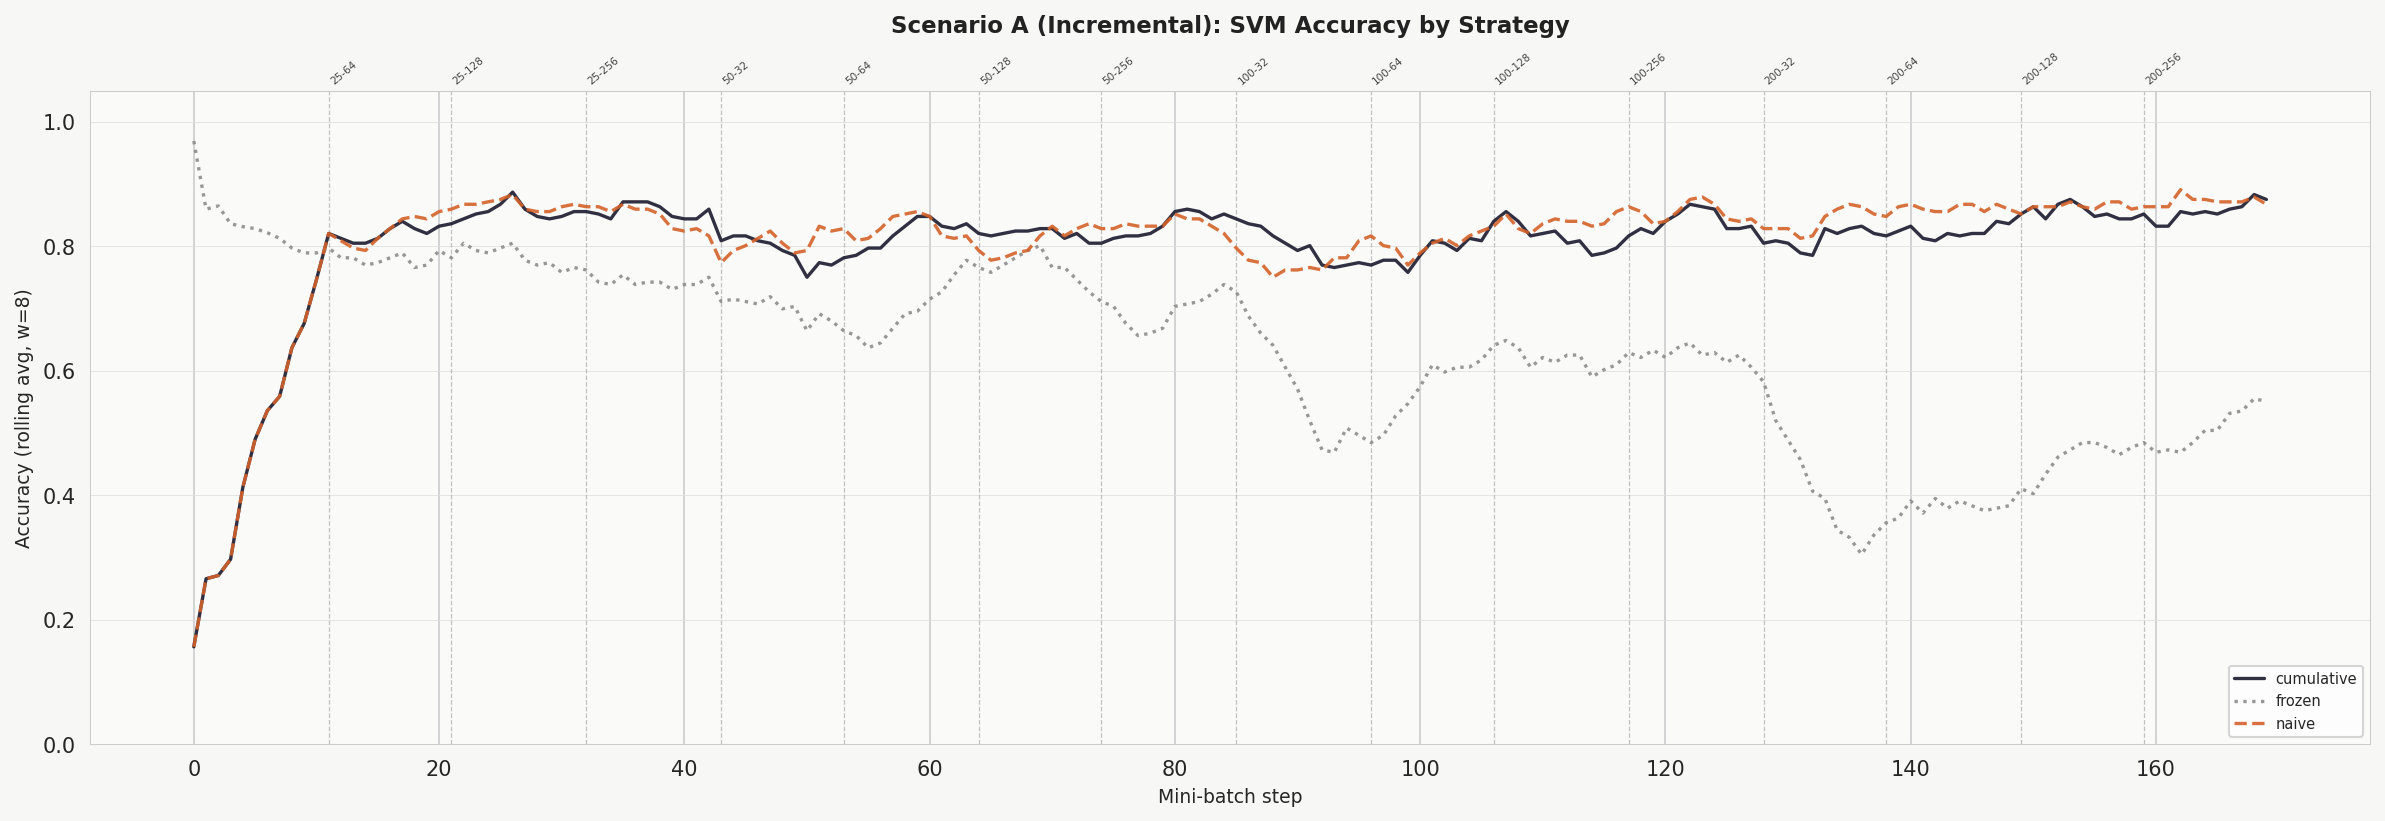


=== Scenario A: KNN across strategies ===


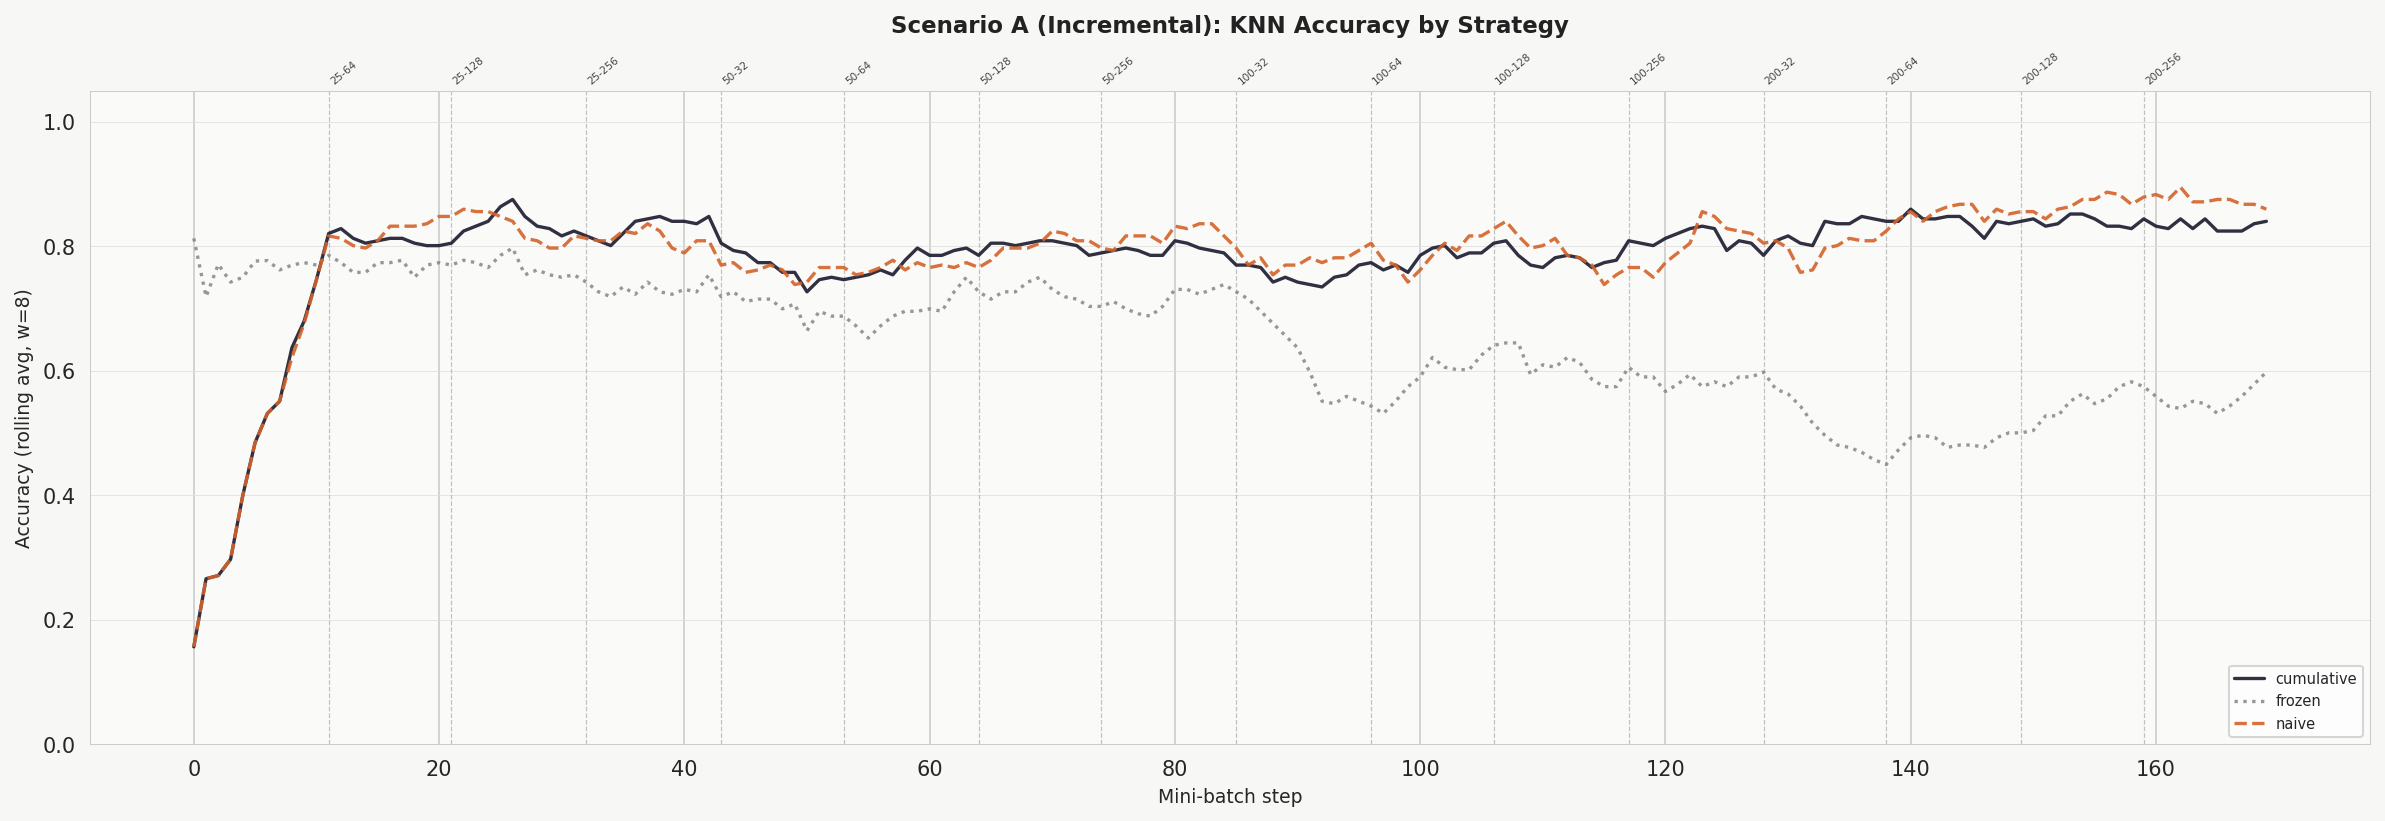

In [ ]:
# Prequential accuracy by strategy for SVM and KNN
print("=== Scenario A: SVM across strategies ===")
viz.plot_accuracy_by_strategy(results_a, model_name="SVM",
    title="Scenario A (Incremental): SVM Accuracy by Strategy")

print("\n=== Scenario A: KNN across strategies ===")
viz.plot_accuracy_by_strategy(results_a, model_name="KNN",
    title="Scenario A (Incremental): KNN Accuracy by Strategy")

=== Scenario A: Heatmap ===


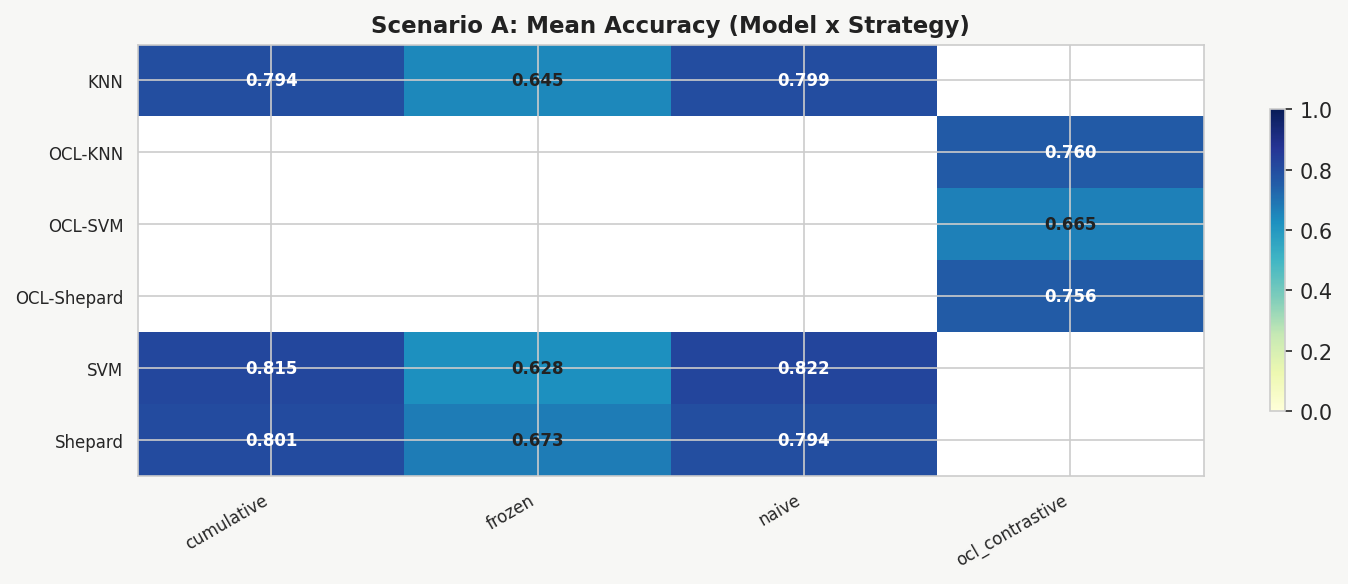

In [ ]:
# Mean-accuracy heatmap across the model x strategy grid
print("=== Scenario A: Heatmap ===")
viz.plot_strategy_summary_heatmap(results_a, metric="accuracy",
    title="Scenario A: Mean Accuracy (Model x Strategy)")

=== Scenario A: Frozen vs Adaptive ===


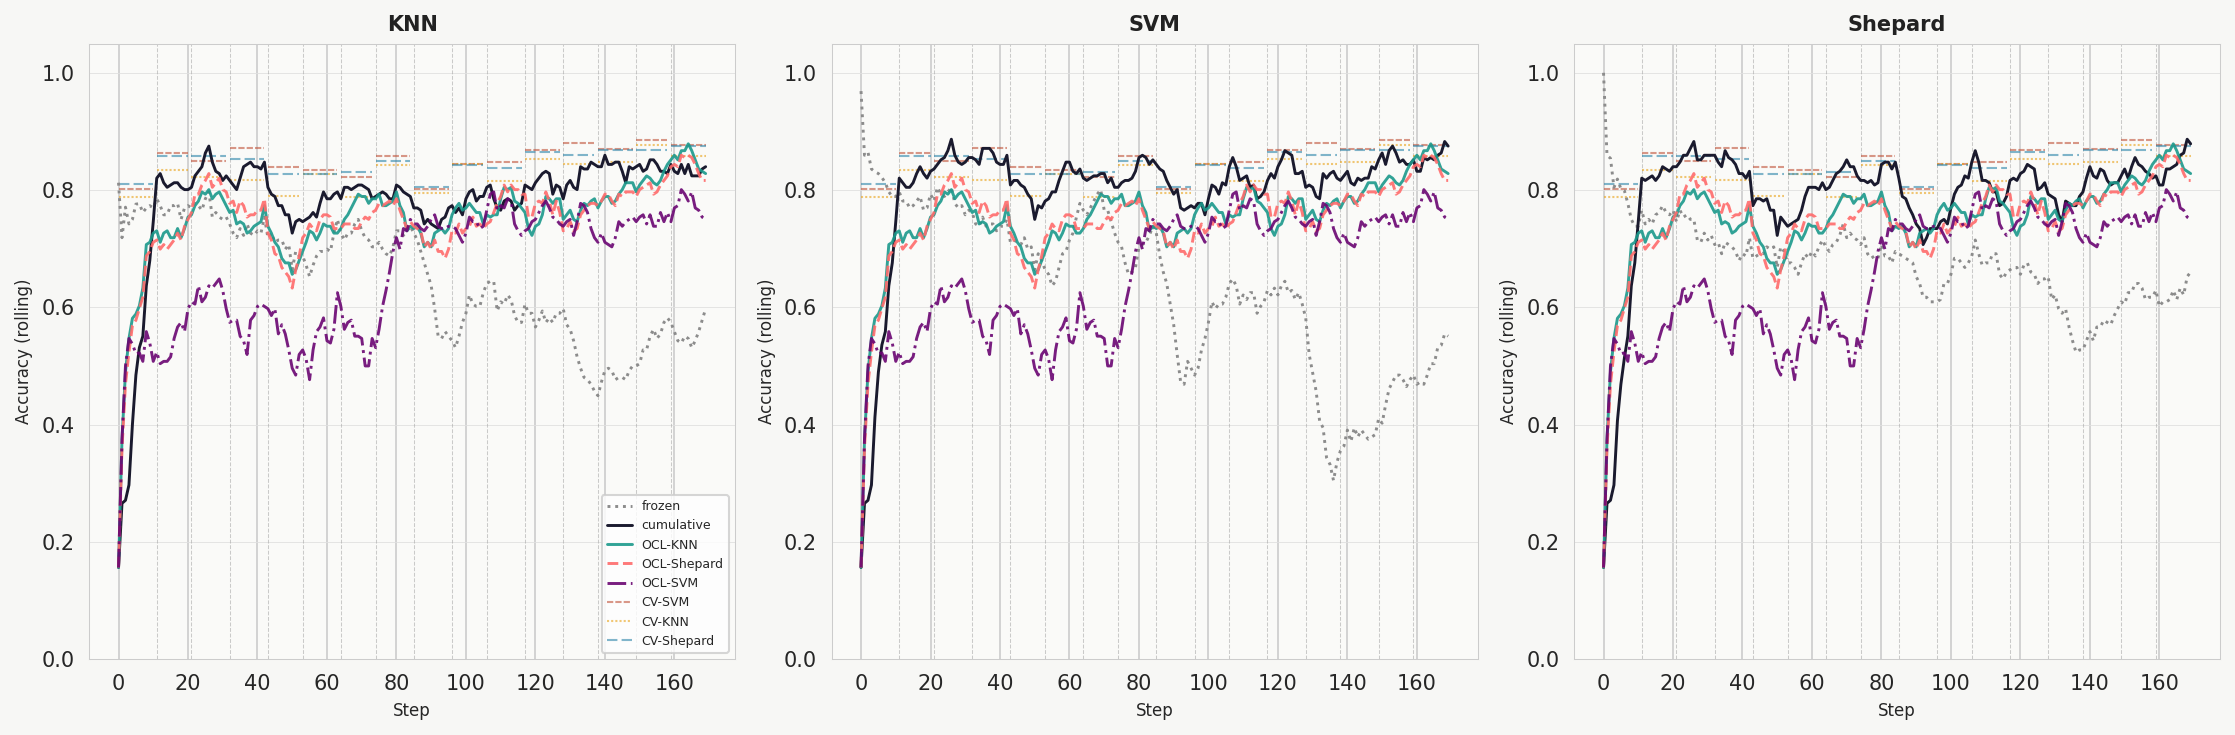

In [ ]:
# Frozen/cumulative baselines vs. OCL, with CV reference overlay
print("=== Scenario A: Frozen vs Adaptive ===")
viz.plot_frozen_vs_ocl(results_a, cv_df=cv_results)

## 11. Results Summary


In [ ]:
print("=" * 80)
print("SCENARIO A: INCREMENTAL DISTRIBUTION STREAM -- FULL RESULTS")
print("=" * 80)
print(f'{"Strategy":<18} {"Model":<14} {"Acc":>7} {"Prec":>7} {"Rec":>7} {"F1":>7} {"MCC":>7}')
print("-" * 80)
# Full mean-metric table (accuracy/precision/recall/F1/MCC) per strategy x model
agg = results_a.groupby(["strategy", "model"])[METRIC_COLS].mean()
for (strat, model), row in agg.iterrows():
    print(
        f"{strat:<18} {model:<14} "
        f"{row['accuracy']:>7.4f} {row['precision']:>7.4f} "
        f"{row['recall']:>7.4f} {row['f1_score']:>7.4f} "
        f"{row['mcc']:>7.4f}"
    )


SCENARIO A: INCREMENTAL DISTRIBUTION STREAM -- FULL RESULTS
Strategy           Model              Acc    Prec     Rec      F1     MCC
--------------------------------------------------------------------------------
cumulative         KNN             0.7943  0.7939  0.7934  0.7793  0.7276
cumulative         SVM             0.8145  0.8169  0.8138  0.7948  0.7593
cumulative         Shepard         0.8009  0.8124  0.8011  0.7834  0.7428
frozen             KNN             0.6454  0.6797  0.6475  0.6176  0.5492
frozen             SVM             0.6281  0.6603  0.6321  0.5940  0.5286
frozen             Shepard         0.6732  0.6169  0.6736  0.6059  0.6046
naive              KNN             0.7993  0.8013  0.8005  0.7870  0.7343
naive              SVM             0.8224  0.8188  0.8205  0.8096  0.7620
naive              Shepard         0.7939  0.7992  0.7980  0.7757  0.7346
ocl_contrastive    OCL-KNN         0.7603  0.7606  0.7631  0.7474  0.6857
ocl_contrastive    OCL-SVM         0.6651  0.

In [ ]:
print("\nFROZEN vs CUMULATIVE DELTA (adaptation gap per classifier)")
print("=" * 80)
# Adaptation gap per classifier: how much cumulative beats frozen on average
for model_name in CFG.sklearn_models:
    frozen = results_a[(results_a["strategy"] == "frozen") & (results_a["model"] == model_name)]["accuracy"]
    cumul  = results_a[(results_a["strategy"] == "cumulative") & (results_a["model"] == model_name)]["accuracy"]
    if len(frozen) > 0 and len(cumul) > 0:
        gap_fc = cumul.mean() - frozen.mean()
        print(
            f"    {model_name:<10} "
            f"frozen={frozen.mean():.4f}  cumul={cumul.mean():.4f}  "
            f"gap(cumul-frozen)={gap_fc:+.4f}"
        )


FROZEN vs CUMULATIVE DELTA (adaptation gap per classifier)
    SVM        frozen=0.6281  cumul=0.8145  gap(cumul-frozen)=+0.1864
    Shepard    frozen=0.6732  cumul=0.8009  gap(cumul-frozen)=+0.1278
    KNN        frozen=0.6454  cumul=0.7943  gap(cumul-frozen)=+0.1489


## 14. Export Results

In [ ]:
# Persist the full per-step results table to results/
results_a.to_csv(f"{CFG.output_dir}/ocl_scenario_a_results-1.0.0.csv", index=False)
print("Exported: ocl_scenario_a_results-1.0.0.csv")

Exported: ocl_scenario_a_results.csv
